<div align="center">

<h1> <b> PÉNDULO MAGNÉTICO: DINÁMICA NO LINEAL Y COMPORTAMIENTO CAÓTICO </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Vergara Restrepo Cristian <br>
Mendoza Montes Bernardo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  
</i></h3>
</div>

---


## Planteamiento del problema

El péndulo magnético combina una restricción geométrica sencilla (un péndulo de longitud fija que oscila bajo la gravedad) con fuerzas no lineales debidas a la interacción con imanes fijos colocados en un plano horizontal por debajo del punto de suspensión. Pese a la sencillez de su formulación, el sistema exhibe una dinámica rica: pequeños cambios en las condiciones iniciales pueden conducir a trayectorias completamente distintas.

En este trabajo se estudia un péndulo de masa puntual, suspendido de un pivote fijo, sometido a tres fuerzas:

- la gravedad,
- una fricción viscosa proporcional a la velocidad,
- y la repulsión magnética de varios imanes fijos situados bajo el pivote.

El objetivo es entender cómo estas tres fuerzas determinan la trayectoria del péndulo y por qué, a partir de condiciones iniciales perfectamente definidas, pueden surgir comportamientos complejos y prácticamente impredecibles. Por esta razón el péndulo magnético es uno de los ejemplos de caos determinista más citados en la literatura: el sistema es completamente determinista, pero su sensibilidad a las condiciones iniciales limita severamente la posibilidad de anticipar, sin simularlo, sobre qué imán terminará atrapado el péndulo.

## Objetivos

### Objetivo general

Modelar numéricamente la dinámica de un péndulo magnético tridimensional y analizar su comportamiento mediante simulación computacional.

### Objetivos específicos

- Formular las ecuaciones de movimiento del péndulo incluyendo las fuerzas gravitatoria, disipativa y magnética.
- Implementar un método de integración temporal que respete la restricción geométrica del sistema (longitud constante del péndulo).
- Visualizar la trayectoria proyectada del péndulo sobre el plano horizontal.
- Calcular el campo magnético efectivo que producen los imanes en el plano inferior.
- Analizar la aparición de comportamiento no lineal y caótico a partir de los resultados obtenidos.

# Metodología y modelo físico

## Descripción del sistema físico

El sistema consiste en una masa puntual $m$ unida a un pivote fijo mediante una cuerda inextensible de longitud $L$. El pivote se ubica a una altura $H$ sobre el plano horizontal donde reposan los imanes.

La posición de la masa se describe en coordenadas cartesianas tridimensionales, pero su movimiento está restringido a la superficie de una esfera de radio $L$ centrada en el pivote.

## Fuerzas consideradas

### Fuerza gravitacional

La fuerza gravitacional actúa verticalmente hacia abajo:

$$
\mathbf{F}_g = (0,\,0,\,-mg)
$$

### Fuerza de fricción viscosa

Se modela como una fuerza disipativa proporcional a la velocidad de la masa:

$$
\mathbf{F}_f = -b\,\mathbf{v}
$$

con $b$ el coeficiente de fricción viscosa.

### Fuerza magnética

Cada imán se modela como una fuente puntual de repulsión, cuya intensidad decae con el cuadrado de la distancia, de forma análoga al campo eléctrico de una carga puntual:

$$
\mathbf{F}_{\text{mag}} = K\,\frac{\mathbf{r}}{|\mathbf{r}|^3}
$$

donde $\mathbf{r}$ es el vector que va del imán a la masa del péndulo y $K$ caracteriza la intensidad del imán. Nótese que, aunque el denominador de la expresión vectorial tiene $|\mathbf{r}|^3$, la magnitud de la fuerza escala como $K/|\mathbf{r}|^2$ (el numerador $\mathbf{r}$ ya aporta un factor $|\mathbf{r}|$). La fuerza magnética total sobre la masa es la suma de las contribuciones de todos los imanes (principio de superposición).

## Restricción geométrica

Como la cuerda no se estira, la masa del péndulo está obligada a moverse sobre una esfera de radio $L$ centrada en el pivote. Para que esta restricción se respete durante la integración numérica, en cada paso de tiempo se procede así:

1. Se calcula la aceleración a partir de la fuerza total.
2. Se descarta la componente radial de esa aceleración, dejando solo la componente tangencial a la esfera.
3. Se corrige la velocidad, eliminando cualquier componente radial que pudiera haber quedado.
4. Se reescala el vector de posición para que su longitud vuelva a ser exactamente $L$.

Este último paso es clave: sin él, los errores de redondeo se irían acumulando paso a paso y, tras suficientes iteraciones, la masa terminaría "flotando" fuera de la esfera permitida.

## Integración temporal

La evolución temporal se calcula con el método de Euler-Cromer (Cromer, 1981), una pequeña modificación del método de Euler explícito que mejora notablemente su estabilidad en sistemas oscilatorios:

$$
\mathbf{v}_{n+1} = \mathbf{v}_n + \mathbf{a}_n \,\Delta t
$$

$$
\mathbf{r}_{n+1} = \mathbf{r}_n + \mathbf{v}_{n+1} \,\Delta t
$$

La diferencia con el Euler explícito estándar es sutil pero importante: la posición se actualiza usando la velocidad *nueva* ($\mathbf{v}_{n+1}$) en vez de la velocidad del paso anterior. Esto evita que la energía del sistema crezca artificialmente con el tiempo, un problema típico del Euler explícito en osciladores. Aunque sigue siendo un método de primer orden, poco preciso frente a esquemas como Runge-Kutta, resulta suficiente para capturar el comportamiento cualitativo de un sistema disipativo como este.

## Implementación computacional

El notebook se organizó en celdas independientes, cada una con una única responsabilidad (parámetros, física, integración, visualización), para que sea más fácil de leer y de reutilizar.

Las funciones que hacen el trabajo pesado (el cálculo de fuerzas y el bucle de integración temporal) se compilan con Numba (Lam et al., 2015) mediante el decorador `@njit`. Numba traduce estas funciones a código máquina la primera vez que se ejecutan, lo que evita la sobrecarga del intérprete de Python en bucles largos. El cálculo del mapa del campo magnético, en particular, es un problema perfectamente paralelo, ya que el valor en cada punto de la malla no depende de los demás: por eso se reparte entre los núcleos disponibles del procesador con `prange`, la versión paralela del `range` de Numba.

Si Numba no está instalado en el entorno donde se ejecuta el notebook, el código no se rompe: se define un decorador de reemplazo que no hace nada, y las funciones corren como Python puro (más lento, pero sin errores).

In [1]:
# =====================================================================
# LIBRERÍAS Y CONFIGURACIÓN DE NUMBA
# =====================================================================
# NumPy: vectores, arreglos y funciones matemáticas básicas.
# Matplotlib: para graficar la trayectoria del péndulo y el mapa de campo.
# LogNorm: permite colorear el mapa de campo en escala logarítmica, ya
#          que su magnitud varía en varios órdenes de entre el centro
#          del sistema y las cercanías de un imán.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import time

# Numba es un compilador "just-in-time" (JIT): toma una función de Python
# escrita con NumPy y bucles explícitos, y la traduce a código máquina la
# primera vez que se ejecuta. Las llamadas siguientes ya no pasan por el
# intérprete de Python, así que corren mucho más rápido (Lam et al., 2015).
# Esto es exactamente lo que necesita este notebook: tanto la simulación
# del péndulo como el cálculo del mapa de campo magnético son bucles
# numéricos puros, el escenario ideal para Numba.
#
# `prange` es la versión paralela de `range`: dentro de una función
# decorada con `@njit(parallel=True)`, un bucle `for i in prange(N):` se
# reparte automáticamente entre los núcleos disponibles del procesador.
try:
    from numba import njit, prange
    NUMBA_DISPONIBLE = True
except ImportError:
    # Si Numba no está instalado, el notebook no debe romperse: se define
    # un decorador "de mentira" que recibe la función y la devuelve sin
    # modificarla. El código sigue siendo válido; solo corre con el
    # intérprete normal de Python (más lento, pero funcional).
    NUMBA_DISPONIBLE = False

    def njit(*jit_args, **jit_kwargs):
        def decorador(func):
            return func
        # Permite usar tanto "@njit" a secas como "@njit(cache=True, ...)"
        if len(jit_args) == 1 and callable(jit_args[0]) and not jit_kwargs:
            return jit_args[0]
        return decorador

    prange = range

print(
    "Numba disponible: las funciones de simulación se compilarán a código "
    "máquina." if NUMBA_DISPONIBLE else
    "Numba no está instalado: el notebook funcionará en Python puro "
    "(más lento). Para acelerarlo, instale Numba con: pip install numba"
)

Numba disponible: las funciones de simulación se compilarán a código máquina.


### Parámetros del sistema

Todos los parámetros físicos y numéricos (masa, longitud, fricción, imanes, condiciones iniciales y paso de tiempo) se agrupan en una sola celda, para poder modificarlos sin tener que buscar valores sueltos por el resto del notebook.

In [2]:
# =====================================================================
# PARÁMETROS FÍSICOS Y NUMÉRICOS DE LA SIMULACIÓN
# =====================================================================

# --- Propiedades del péndulo ---
m = 1.0      # Masa de la partícula en el extremo del péndulo (kg)
L = 1.0      # Longitud de la cuerda: el radio de la esfera sobre la que
             # se mueve la masa (m)
H = L / 5    # Altura del pivote sobre el plano donde están los imanes (m).
             # Si H fuera muy grande, la masa nunca se acercaría lo
             # suficiente a los imanes como para sentir su atracción.
g = 9.81     # Aceleración de la gravedad (m/s^2)
b = 0.1      # Coeficiente de fricción viscosa: controla qué tan rápido
             # el péndulo pierde energía y su movimiento se va apagando.

# --- Imanes ---
# Cada imán se define como una tupla (x, y, z, K):
#   (x, y, z): posición del imán en el espacio (m)
#   K: intensidad de la repulsión magnética que ejerce ese imán
# Los tres imanes forman un triángulo alrededor del punto que queda
# justo debajo del pivote (el origen del plano xy).
imanes = [
    (0.2, 0.0, 0.0, 2.0),
    (-0.2, 0.2, 0.0, 2.0),
    (-0.2, -0.2, 0.0, 2.0),
]

# Numba trabaja mejor con arreglos de NumPy que con listas de tuplas de
# Python, así que se convierte la lista anterior en una matriz de forma
# (n_imanes, 4): cada fila es un imán y las columnas son x, y, z, K.
imanes_array = np.array(imanes, dtype=np.float64)

# Verificación de coherencia física: el modelo supone que los tres
# imanes repelen a la masa (K > 0), tal como se describe en la
# metodología. Un valor de K negativo no generaría ningún error de
# ejecución, pero convertiría silenciosamente la repulsión en
# atracción, invalidando la dinámica de "péndulo magnético" sin
# ningún aviso visible. Se comprueba explícitamente para evitar ese
# tipo de error silencioso.
if np.any(imanes_array[:, 3] <= 0):
    raise ValueError(
        "Todos los imanes deben tener K > 0 (repulsión); se encontró "
        "un valor no positivo en la columna K de imanes_array."
    )

# --- Condiciones iniciales del péndulo ---
# La posición inicial se da en coordenadas esféricas, porque es más
# natural describir "qué tan inclinado" y "hacia dónde" parte el péndulo
# que dar directamente sus coordenadas (x, y, z).
#   theta0: ángulo entre la cuerda y la vertical (eje z) hacia abajo
#   phi0:   ángulo azimutal, medido desde el eje x en el plano xy
theta0 = np.radians(50)
phi0 = np.radians(20)

# --- Parámetros temporales ---
T = 55.0    # Tiempo total simulado (s)
dt = 0.01   # Paso de tiempo de la integración (s). Un dt más pequeño da
            # una trayectoria más precisa, a costa de más pasos de cálculo.

### Funciones físicas y motor de simulación

A continuación se definen las funciones que calculan la fuerza sobre el péndulo, aplican la restricción geométrica, integran la trayectoria en el tiempo y calculan el mapa del campo magnético efectivo.

In [3]:
# =====================================================================
# FUNCIONES FÍSICAS: FUERZA MAGNÉTICA Y RESTRICCIÓN GEOMÉTRICA
# =====================================================================
# Estas dos funciones se llaman miles de veces dentro del bucle de la
# simulación (una vez por paso de tiempo), así que son las que más se
# benefician de compilarse con Numba. Por eso reciben las coordenadas
# como números sueltos (x, y, z) en vez de como un arreglo de NumPy: así
# Numba no tiene que crear y destruir un arreglo pequeño en cada llamada,
# lo cual sería un desperdicio de tiempo dentro de un bucle tan largo.

@njit(cache=True)
def fuerza_magnetica_total(x, y, z, imanes_array, eps=1e-8):
    """
    Calcula la fuerza magnética neta sobre la masa del péndulo, situada
    en el punto (x, y, z), debida a todos los imanes.

    Cada imán repele a la masa con una fuerza que apunta radialmente
    hacia afuera del imán y cuya magnitud decae con el cuadrado de la
    distancia (de forma análoga al campo eléctrico de una carga puntual):

        F_imán = K * r_vec / |r_vec|^3   ->   |F_imán| = K / |r_vec|^2

    donde r_vec es el vector que va del imán a la masa, y K mide qué tan
    intenso es ese imán. La fuerza total es la suma vectorial de la
    contribución de cada imán (principio de superposición).

    El parámetro eps evita una división por cero en el caso (físicamente
    imposible, pero numéricamente posible) de que la masa pase justo por
    encima de un imán, donde la distancia sería cero.
    """
    Fx, Fy, Fz = 0.0, 0.0, 0.0
    n_imanes = imanes_array.shape[0]

    for k in range(n_imanes):
        xi = imanes_array[k, 0]
        yi = imanes_array[k, 1]
        zi = imanes_array[k, 2]
        K = imanes_array[k, 3]

        # Vector desde el imán k hasta la posición actual de la masa
        rx = x - xi
        ry = y - yi
        rz = z - zi
        d = np.sqrt(rx * rx + ry * ry + rz * rz)  # distancia al imán

        if d > eps:
            factor = K / (d ** 3)
            Fx += rx * factor
            Fy += ry * factor
            Fz += rz * factor

    return Fx, Fy, Fz


@njit(cache=True)
def proyectar_tangencial(Fx, Fy, Fz, rx, ry, rz, r_norm):
    """
    Descompone una fuerza (Fx, Fy, Fz) en su componente radial y su
    componente tangencial respecto a la esfera de radio L en la que se
    mueve el péndulo, y devuelve solo la parte tangencial.

    (rx, ry, rz) es el vector que va del pivote a la masa, y r_norm es
    su longitud (debería ser siempre L, salvo errores numéricos).

    Esto es necesario porque, aunque la gravedad, la fricción y el campo
    magnético no "saben" que el péndulo está restringido a una esfera,
    la cuerda sí impone esa restricción: cualquier componente de la
    fuerza dirigida a lo largo de la cuerda (radial) solo la tensiona o
    la afloja, pero no puede mover la masa ni hacia adentro ni hacia
    afuera de la esfera. Solo la componente perpendicular a la cuerda
    (tangencial) produce movimiento real.
    """
    if r_norm == 0.0:
        # Caso degenerado (la masa coincidiría con el pivote): no hay una
        # dirección radial bien definida, así que se devuelve la fuerza
        # sin modificar.
        return Fx, Fy, Fz

    # Vector unitario en la dirección radial (del pivote hacia la masa)
    rhat_x = rx / r_norm
    rhat_y = ry / r_norm
    rhat_z = rz / r_norm

    # Componente radial de la fuerza: su proyección sobre r_hat
    F_radial = Fx * rhat_x + Fy * rhat_y + Fz * rhat_z

    # La componente tangencial es lo que queda al restar la radial
    Ftan_x = Fx - F_radial * rhat_x
    Ftan_y = Fy - F_radial * rhat_y
    Ftan_z = Fz - F_radial * rhat_z

    return Ftan_x, Ftan_y, Ftan_z

In [4]:
# =====================================================================
# INTEGRACIÓN TEMPORAL: MÉTODO DE EULER-CROMER
# =====================================================================

@njit(cache=True)
def simular_pendulo(m, L, H, g, b, imanes_array, theta0, phi0, T, dt):
    """
    Simula la trayectoria del péndulo magnético entre t = 0 y t = T,
    usando el método de Euler-Cromer (Cromer, 1981) y aplicando en cada
    paso la restricción geométrica de longitud constante L.

    Devuelve dos arreglos, xs e ys, con la proyección de la trayectoria
    sobre el plano horizontal (la vista "desde arriba" del movimiento).

    Resumen del procedimiento, repetido en cada paso de tiempo dt:
      1. Sumar todas las fuerzas que actúan sobre la masa.
      2. Quedarse solo con la parte de esa fuerza que es tangencial a la
         esfera de radio L (ver `proyectar_tangencial`).
      3. Actualizar primero la velocidad con esa aceleración tangencial.
      4. Eliminar cualquier componente radial que haya quedado en la
         velocidad ya actualizada (la cuerda tampoco lo permite).
      5. Actualizar la posición con la velocidad ya corregida.
      6. Reescalar la posición para que quede exactamente a distancia L
         del pivote, corrigiendo los pequeños errores de redondeo que se
         acumulan con cada paso.
    """
    n_steps = int(T / dt)

    # --- Posición inicial, a partir de los ángulos esféricos ---
    # theta0 se mide desde el eje z (hacia abajo) y phi0 desde el eje x,
    # en el plano horizontal. H es la altura del pivote sobre el plano de
    # los imanes, así que la coordenada z de la masa queda medida
    # relativa a ese plano (z = 0 a la altura de los imanes).
    x = L * np.sin(theta0) * np.cos(phi0)
    y = L * np.sin(theta0) * np.sin(phi0)
    z = H - L * np.cos(theta0)

    # La masa parte del reposo
    vx, vy, vz = 0.0, 0.0, 0.0

    # El pivote está justo encima del origen del plano de los imanes
    piv_x, piv_y, piv_z = 0.0, 0.0, H

    # Se reserva de antemano la memoria para toda la trayectoria proyectada
    # (más eficiente que ir agrandando una lista paso a paso).
    xs = np.empty(n_steps)
    ys = np.empty(n_steps)

    for paso in range(n_steps):
        # Se guarda la posición ANTES de actualizarla, para que el primer
        # punto registrado sea la posición inicial real del péndulo.
        xs[paso] = x
        ys[paso] = y

        # --- Paso 1: sumar todas las fuerzas ---
        Fg_x, Fg_y, Fg_z = 0.0, 0.0, -m * g            # gravedad
        Fm_x, Fm_y, Fm_z = fuerza_magnetica_total(x, y, z, imanes_array)
        Ff_x, Ff_y, Ff_z = -b * vx, -b * vy, -b * vz    # fricción viscosa

        Ft_x = Fg_x + Fm_x + Ff_x
        Ft_y = Fg_y + Fm_y + Ff_y
        Ft_z = Fg_z + Fm_z + Ff_z

        # Vector del pivote a la masa (antes de mover nada en este paso)
        rx = x - piv_x
        ry = y - piv_y
        rz = z - piv_z
        r_norm = np.sqrt(rx * rx + ry * ry + rz * rz)

        # --- Paso 2: quedarse solo con la parte tangencial de la fuerza ---
        Ftan_x, Ftan_y, Ftan_z = proyectar_tangencial(
            Ft_x, Ft_y, Ft_z, rx, ry, rz, r_norm
        )
        ax, ay, az = Ftan_x / m, Ftan_y / m, Ftan_z / m

        # --- Paso 3: actualizar la velocidad (Euler-Cromer) ---
        vx += ax * dt
        vy += ay * dt
        vz += az * dt

        # --- Paso 4: quitarle a la velocidad su componente radial ---
        # (rx, ry, rz) y r_norm siguen siendo válidos aquí: la posición
        # todavía no se ha actualizado en este paso.
        rhat_x = rx / r_norm
        rhat_y = ry / r_norm
        rhat_z = rz / r_norm
        v_radial = vx * rhat_x + vy * rhat_y + vz * rhat_z
        vx -= v_radial * rhat_x
        vy -= v_radial * rhat_y
        vz -= v_radial * rhat_z

        # --- Paso 5: actualizar la posición (Euler-Cromer) ---
        x += vx * dt
        y += vy * dt
        z += vz * dt

        # --- Paso 6: reescalar la posición para que |pos - pivote| = L ---
        rx = x - piv_x
        ry = y - piv_y
        rz = z - piv_z
        r_norm_nuevo = np.sqrt(rx * rx + ry * ry + rz * rz)
        x = piv_x + L * rx / r_norm_nuevo
        y = piv_y + L * ry / r_norm_nuevo
        z = piv_z + L * rz / r_norm_nuevo

    return xs, ys

In [5]:
# =====================================================================
# MAPA DEL CAMPO MAGNÉTICO EFECTIVO EN EL PLANO z = 0
# =====================================================================

@njit(cache=True, parallel=True)
def calcular_mapa_campo(imanes_array, N=300, r_max=0.5, eps=1e-6):
    """
    Calcula, sobre una malla de N x N puntos en el plano z = 0, la
    magnitud de la componente horizontal (x, y) de la fuerza magnética
    que sentiría una masa de prueba situada en cada punto.

    Este mapa no es la trayectoria de ningún péndulo en particular: es
    una "fotografía" estática del campo de fuerzas horizontal generado
    por los imanes, útil para entender por qué el sistema es tan
    sensible cerca del centro (donde las contribuciones de los tres
    imanes casi se cancelan) y tan predecible cerca de cada imán (donde
    domina claramente una sola contribución).

    Cada punto de la malla es independiente de los demás: el cálculo en
    (i, j) no necesita el resultado de ningún otro punto. Por eso este
    problema es "perfectamente paralelo" y se reparte entre los núcleos
    del procesador con `prange` en el bucle exterior (sobre las filas).
    """
    xs = np.linspace(-r_max, r_max, N)
    ys = np.linspace(-r_max, r_max, N)
    mapa = np.zeros((N, N))
    n_imanes = imanes_array.shape[0]

    for i in prange(N):          # <- bucle paralelizado (una fila por hilo)
        py = ys[i]
        for j in range(N):
            px = xs[j]

            Bx, By = 0.0, 0.0
            for k in range(n_imanes):
                xi = imanes_array[k, 0]
                yi = imanes_array[k, 1]
                zi = imanes_array[k, 2]
                K = imanes_array[k, 3]

                rx = px - xi
                ry = py - yi
                rz = 0.0 - zi
                d = np.sqrt(rx * rx + ry * ry + rz * rz)

                if d > eps:
                    factor = K / (d ** 3)
                    # Solo se acumula la parte horizontal de la fuerza:
                    # es la que efectivamente empujaría a una masa que se
                    # moviera libremente sobre el plano z = 0.
                    Bx += rx * factor
                    By += ry * factor

            mapa[i, j] = np.sqrt(Bx * Bx + By * By)

    return xs, ys, mapa

### Ejecución y visualización de resultados

Con las funciones ya definidas, se corre la simulación, se mide el tiempo de cómputo y se generan las dos figuras del informe.

In [6]:
# =====================================================================
# EJECUCIÓN DE LA SIMULACIÓN
# =====================================================================
# La primera vez que se llama a una función decorada con @njit, Numba
# tiene que compilarla, así que esa primera ejecución es más lenta de lo
# normal. Las llamadas siguientes, con los mismos tipos de datos,
# reutilizan el código ya compilado y son mucho más rápidas. El tiempo
# medido a continuación incluye ese costo de compilación.

inicio = time.time()
xs, ys = simular_pendulo(m, L, H, g, b, imanes_array, theta0, phi0, T, dt)
print(f"Trayectoria del péndulo calculada en {time.time() - inicio:.3f} s "
      f"({int(T / dt)} pasos de tiempo)")

inicio = time.time()
grid_x, grid_y, Bmap = calcular_mapa_campo(imanes_array)
print(f"Mapa del campo magnético calculado en {time.time() - inicio:.3f} s "
      f"({Bmap.size} puntos de la malla)")

# Se recortan los valores del mapa para que no haya ceros (ni negativos)
# al aplicar la escala logarítmica en la Figura 2: log(0) no está definido.
Bplot = np.clip(Bmap, 1e-6, None)

Trayectoria del péndulo calculada en 5.852 s (5500 pasos de tiempo)
Mapa del campo magnético calculado en 4.097 s (90000 puntos de la malla)


In [7]:
# =====================================================================
# ESTILO COMÚN DE LAS FIGURAS
# =====================================================================
FIGSIZE = (7, 6)     # Tamaño de cada figura, en pulgadas
DPI = 120            # Resolución de la figura
MARKER_SIZE = 60     # Tamaño de los marcadores (imanes, pivote, etc.)
CAPTION_Y = -0.14    # Posición vertical del pie de figura, debajo del eje x

# Coordenadas (x, y) de los imanes, para dibujarlos sobre las figuras
xim = [xi for (xi, yi, zi, K) in imanes]
yim = [yi for (xi, yi, zi, K) in imanes]

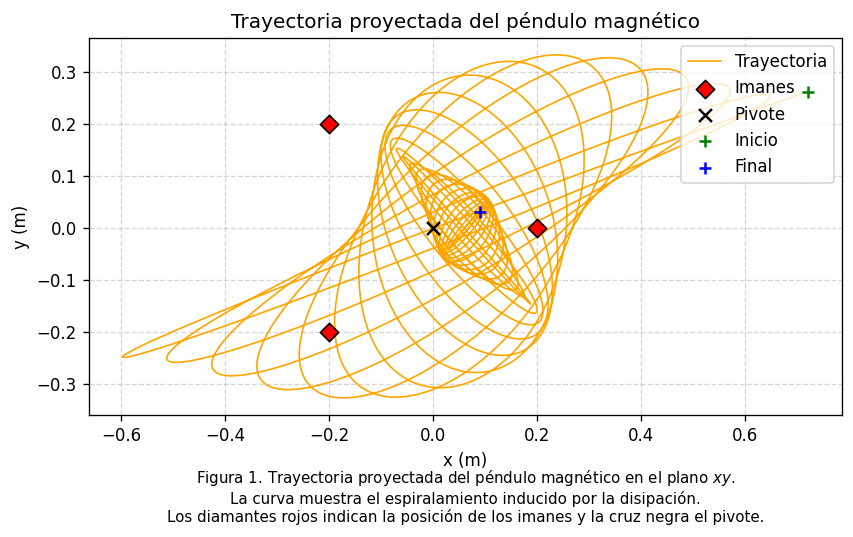

In [8]:
# =====================================================================
# FIGURA 1: TRAYECTORIA PROYECTADA DEL PÉNDULO
# =====================================================================
fig1, ax1 = plt.subplots(figsize=FIGSIZE, dpi=DPI, constrained_layout=True)

ax1.plot(xs, ys, color='orange', linewidth=1, label='Trayectoria')
ax1.scatter(xim, yim, c='red', s=MARKER_SIZE, marker='D',
            edgecolors='black', label='Imanes', zorder=5)
ax1.scatter(0, 0, c='black', marker='x', s=MARKER_SIZE,
            label='Pivote', zorder=6)
ax1.scatter(xs[0], ys[0], c='green', marker='+', s=MARKER_SIZE,
            label='Inicio', zorder=6)
ax1.scatter(xs[-1], ys[-1], c='blue', marker='+', s=MARKER_SIZE,
            label='Final', zorder=6)

ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.set_title('Trayectoria proyectada del péndulo magnético')
ax1.set_aspect('equal')  # Para que un círculo se vea como un círculo, y
                          # no como una elipse
ax1.grid(True, linestyle='--', alpha=0.5)

# Usar un diccionario elimina automáticamente etiquetas repetidas en la
# leyenda (por ejemplo, si "Imanes" apareciera más de una vez).
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(dict(zip(labels, handles)).values(),
           dict(zip(labels, handles)).keys(),
           loc='upper right')

ax1.text(
    0.5, CAPTION_Y,
    "Figura 1. Trayectoria proyectada del péndulo magnético en el plano $xy$.\n"
    "La curva muestra el espiralamiento inducido por la disipación.\n"
    "Los diamantes rojos indican la posición de los imanes y la cruz negra el pivote.",
    transform=ax1.transAxes, ha='center', va='top', fontsize=9
)

plt.show()

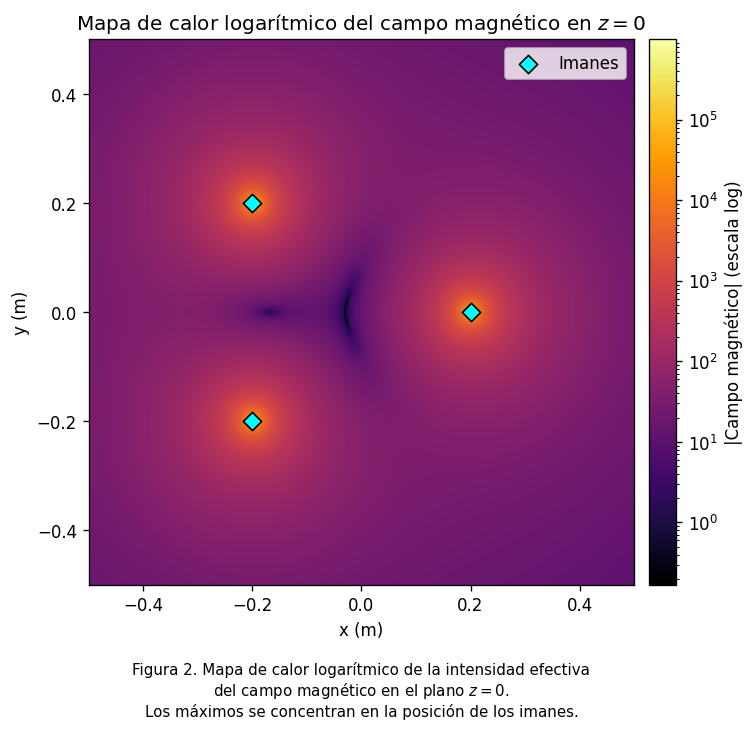

In [9]:
# =====================================================================
# FIGURA 2: MAPA DE CALOR DEL CAMPO MAGNÉTICO EFECTIVO
# =====================================================================
fig2, ax2 = plt.subplots(figsize=FIGSIZE, dpi=DPI, constrained_layout=True)

# Se usa una escala logarítmica de color porque el campo magnético varía
# en varios órdenes de magnitud entre el centro del sistema y las
# cercanías inmediatas de un imán; en escala lineal esas variaciones,
# pequeñas pero importantes cerca del centro, quedarían invisibles.
norm = LogNorm(vmin=Bplot.min(), vmax=Bplot.max())
im = ax2.imshow(
    Bplot,
    extent=[grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()],
    origin='lower',
    cmap='inferno',
    norm=norm
)

ax2.scatter(xim, yim, c='cyan', s=MARKER_SIZE, marker='D',
            edgecolors='black', label='Imanes', zorder=5)

ax2.set_xlabel('x (m)')
ax2.set_ylabel('y (m)')
ax2.set_title('Mapa de calor logarítmico del campo magnético en $z=0$')

cbar = fig2.colorbar(im, ax=ax2, pad=0.02)
cbar.set_label('|Campo magnético| (escala log)')

ax2.legend(loc='upper right')

ax2.text(
    0.5, CAPTION_Y,
    "Figura 2. Mapa de calor logarítmico de la intensidad efectiva\n"
    "del campo magnético en el plano $z=0$.\n"
    "Los máximos se concentran en la posición de los imanes.",
    transform=ax2.transAxes, ha='center', va='top', fontsize=9
)

plt.show()

# Resultados, análisis y conclusiones

## Resultados

La Figura 1 muestra la trayectoria proyectada del péndulo sobre el plano $xy$. El movimiento es oscilatorio y se va cerrando hacia el centro a medida que la fricción disipa energía: se observan lazos que se estrechan y precesan, resultado del intercambio continuo entre las componentes tangencial y radial de la fuerza que impone la restricción de longitud constante. Con las condiciones iniciales usadas ($\theta_0=50^\circ$, $\phi_0=20^\circ$), el péndulo queda atrapado en la cuenca de atracción del imán ubicado en $(0.2,\,0.0)$: su posición de equilibrio final se desplaza hacia ese imán, sin llegar a coincidir con su posición exacta, porque la gravedad conserva parte de su efecto restaurador hacia el reposo vertical.

La Figura 2 muestra, en escala logarítmica, la magnitud del campo magnético efectivo sobre el plano $z=0$. Se distinguen tres máximos que coinciden con la posición de los imanes, y una región central de menor intensidad con estructura de silla de montar, donde las tres repulsiones se compensan parcialmente. Esa región central es la más sensible a variaciones pequeñas en la posición o la velocidad del péndulo, y es la que hace que las fronteras entre las cuencas de atracción de los distintos imanes sean, en general, fractales.

## Análisis

La forma final de la trayectoria depende fuertemente de las condiciones iniciales: un cambio pequeño en el ángulo o en la velocidad de partida puede alterar el número de lazos que describe el péndulo antes de quedar atrapado, e incluso decidir sobre qué imán termina la trayectoria. Este es, en este sistema, el mecanismo detrás del efecto mariposa descrito originalmente por Lorenz (1963).

El coeficiente de fricción $b$ también determina el carácter de la solución: con $b$ alto la energía se disipa rápido, el péndulo recorre pocas órbitas y queda atrapado con rapidez; con $b$ bajo, el péndulo pasa más tiempo explorando la región central, lo que aumenta la sensibilidad del resultado final frente a las condiciones iniciales.

Conviene precisar la ley de fuerza usada. El código implementa $\mathbf{F}_{\text{mag}} = K\,\mathbf{r}/|\mathbf{r}|^3$, así que su magnitud decae como $K/|\mathbf{r}|^2$: es una ley de tipo inverso al cuadrado, análoga al campo eléctrico de una carga puntual, y no una ley $1/r^3$. Otras leyes de decaimiento (por ejemplo, una con saturación a corta distancia) producirían cuencas de atracción de forma distinta y cambiarían la dinámica transitoria del sistema.

## Conclusiones

La simulación reproduce el comportamiento esperado de un péndulo magnético con tres atractores: sensibilidad a las condiciones iniciales, trayectorias con lazos y precesión, y una relación entre la posición inicial y el imán de captura que es clara en retrospectiva pero difícil de anticipar sin simular. El esquema numérico utilizado (Euler-Cromer con corrección geométrica explícita, Cromer, 1981) es suficiente para capturar este comportamiento cualitativo. Un análisis cuantitativo más fino, por ejemplo la determinación precisa de tiempos de captura o de exponentes de Lyapunov, requeriría un integrador de mayor orden o un paso de tiempo más pequeño (Strogatz, 2024).

## Trabajo futuro

- **Mapa completo de cuencas de atracción.** Repetir la simulación para una malla de condiciones iniciales y colorear cada punto según el imán de captura, en la línea de las visualizaciones clásicas de Beltoforion (s. f.). Gracias a la paralelización con Numba, este barrido (que implica miles de simulaciones independientes) resulta computacionalmente viable en un tiempo razonable.
- **Barridos paramétricos.** Explorar sistemáticamente el efecto de $b$, $K$, $L$ y la ley de decaimiento de la fuerza sobre la forma de las cuencas y los tiempos de captura.
- **Integradores de mayor orden.** Implementar Runge-Kutta de cuarto orden (RK4) o un esquema de paso adaptativo, y comparar la robustez de los resultados frente al método de Euler-Cromer.
- **Animaciones.** Generar animaciones de trayectorias individuales o de conjuntos de trayectorias, útiles para presentaciones o para la defensa del trabajo.

## Referencias

### Fundamentos teóricos y numéricos

Cromer, A. (1981). Stable solutions using the Euler approximation. *American Journal of Physics*, *49*(5), 455-459. https://doi.org/10.1119/1.12478

Lorenz, E. N. (1963). Deterministic nonperiodic flow. *Journal of the Atmospheric Sciences*, *20*(2), 130-141. https://doi.org/10.1175/1520-0469(1963)020<0130:DNF>2.0.CO;2

Strogatz, S. H. (2024). *Nonlinear dynamics and chaos: With applications to physics, biology, chemistry, and engineering* (3.ª ed.). CRC Press.

Lam, S. K., Pitrou, A., & Seibert, S. (2015). Numba: A LLVM-based Python JIT compiler. En *Proceedings of the Second Workshop on the LLVM Compiler Infrastructure in HPC* (LLVM '15), artículo 7. Association for Computing Machinery. https://doi.org/10.1145/2833157.2833162

### Recursos complementarios

Berg, I. (Beltoforion). (s. f.). *The magnetic pendulum: Hands-on chaos theory*. beltoforion.de. Recuperado el 19 de septiembre de 2026, de https://beltoforion.de/en/magnetic-pendulum

Nylander, P. (s. f.). *Fractals*. Recuperado de http://www.bugman123.com/Fractals/index.html

Muller, D. [Veritasium]. (2019, 6 de diciembre). *Chaos: The science of the butterfly effect* [Video]. YouTube. https://www.youtube.com/watch?v=fDek6cYijxI

MIT OpenCourseWare. (2016). *Lorenz attractor and chaos* [Video]. YouTube. https://www.youtube.com/watch?v=Q_f1vRLAENA